# Fate of the Solar Eclipse
## Evolution of the Moon–Sun Angular Size Ratio
**Clover Lee — Spring 2026**

---

This notebook models how the apparent angular sizes of the Moon and Sun change over time due to lunar recession, and estimates when total solar eclipses will no longer be possible.

### Outline
1. Imports & physical constants
2. Angular size model
3. NASA eclipse catalog — data loading & cleaning
4. Plot 1: Moon angular diameter vs. time
5. Plot 2: Moon/Sun angular size ratio $R(t)$ vs. time
6. Plot 3: Superimposed Sun & Moon disk comparison
7. Interactive widget: eclipse type by year

---
## 1. Imports & Physical Constants

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from IPython.display import display

# Optional — uncomment if you want to use astropy units
# from astropy import units as u

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
# ── Physical constants (all distances in km) ──────────────────────────────────

D_moon = 3_474.8          # Moon diameter (km)
D_sun  = 1_392_700.0      # Sun diameter (km)

d_moon_0 = 384_400.0      # Current mean Earth-Moon distance (km)
d_sun    = 149_597_870.0  # Mean Earth-Sun distance (km, 1 AU)

# Lunar recession rate: 3.8 cm/yr → convert to km/yr
v_recession = 3.8e-5      # km/yr

# Reference year ("t = 0" in our model)
YEAR_0 = 2026

print(f"Moon diameter:          {D_moon:,.1f} km")
print(f"Sun diameter:           {D_sun:,.0f} km")
print(f"Earth-Moon distance:    {d_moon_0:,.0f} km")
print(f"Earth-Sun distance:     {d_sun:,.0f} km")
print(f"Recession rate:         {v_recession:.2e} km/yr")

Moon diameter:          3,474.8 km
Sun diameter:           1,392,700 km
Earth-Moon distance:    384,400 km
Earth-Sun distance:     149,597,870 km
Recession rate:         3.80e-05 km/yr


---
## 2. Angular Size Model

The small-angle approximation gives angular diameter:
$$\theta \approx \frac{D}{d}$$

The Moon's distance grows linearly with time due to tidal recession:
$$d_\text{Moon}(t) = d_0 + v \cdot (t - t_0)$$

The angular size ratio we care about is:
$$R(t) = \frac{\theta_\text{Moon}(t)}{\theta_\text{Sun}} = \frac{D_\text{Moon} / d_\text{Moon}(t)}{D_\text{Sun} / d_\text{Sun}}$$

Total solar eclipses are only possible when $R(t) \geq 1$.

In [19]:
# ── Time array: from 1 million years ago to 1 million years in the future ────
# (adjust range as needed — the crossover happens in ~600 million years)

years = np.linspace(-500_000_000, 1_500_000_000, 10_000)  # years from YEAR_0

def moon_distance(t_offset_yr):
    """Earth-Moon distance (km) at t_offset years from YEAR_0."""
    return d_moon_0 + v_recession * t_offset_yr

def angular_size(diameter_km, distance_km):
    """Angular diameter in radians (small-angle approx: theta = D/d)."""
    return diameter_km / distance_km

def ratio_R(t_offset_yr):
    """Moon/Sun angular size ratio at t_offset years from YEAR_0."""
    theta_moon = angular_size(D_moon, moon_distance(t_offset_yr))
    theta_sun  = angular_size(D_sun,  d_sun)
    return theta_moon / theta_sun

# Compute arrays
d_moon_arr   = moon_distance(years)
theta_moon_arr = angular_size(D_moon, d_moon_arr)
R_arr          = ratio_R(years)

# ── Find the crossover year (R = 1) ──────────────────────────────────────────
# R(t) = 1  →  solve for t
# D_moon / (d0 + v*t) = D_sun / d_sun
# t = (D_moon * d_sun / D_sun - d0) / v

t_crossover = (D_moon * d_sun / D_sun - d_moon_0) / v_recession
year_crossover = YEAR_0 + t_crossover

print(f"Current R (today):        {ratio_R(0):.4f}")
print(f"Crossover in:             {t_crossover/1e6:.1f} million years")
print(f"Crossover year (approx):  {year_crossover:.2e}")

Current R (today):        0.9710
Crossover in:             -293.5 million years
Crossover year (approx):  -2.93e+08


---
## 3. NASA Eclipse Catalog — Data Loading & Cleaning

Data source: [NASA Five Millennium Canon of Solar Eclipses](https://eclipse.gsfc.nasa.gov/5MCSE/5MKSEcatalog.txt)

> **Tip:** Download this file once and save it locally as `5MKSEcatalog.txt` in this folder to avoid re-fetching it every run.

In [20]:
# ── Load NASA catalog ─────────────────────────────────────────────────────────
# Try local file first; fall back to URL

import os

LOCAL_PATH = "5MKSEcatalog.txt"
NASA_URL   = "https://eclipse.gsfc.nasa.gov/5MCSE/5MKSEcatalog.txt"

source = LOCAL_PATH if os.path.exists(LOCAL_PATH) else NASA_URL
print(f"Loading from: {source}")

# Column widths for the fixed-width format (inspect header to confirm)
# Format reference: https://eclipse.gsfc.nasa.gov/5MCSE/5MCSEcat.html
col_names = [
    "Cat_Num", "Cat_Plate", "Year", "Month", "Day",
    "Greatest_Eclipse", "DT_s", "Luna_Num", "Saros_Num",
    "Ecl_Type", "QLE", "Gamma", "Ecl_Mag",
    "Lat", "Long", "Sun_Alt", "Sun_Azm",
    "Path_Width_km", "Central_Line_Dur"
]

df_raw = pd.read_fwf(
    source,
    skiprows=10,
    header=None,
    encoding="latin1"
)

# Assign column names (trim to actual number of columns)
df_raw.columns = col_names[:len(df_raw.columns)]

df_raw.head()

Loading from: https://eclipse.gsfc.nasa.gov/5MCSE/5MKSEcatalog.txt


,Cat_Num,Cat_Plate,Year,Month,Day,Greatest_Eclipse,DT_s,Luna_Num,Saros_Num,Ecl_Type,QLE,Gamma,Ecl_Mag,Lat,Long,Sun_Alt,Sun_Azm,Path_Width_km,Central_Line_Dur
0,1,1,-1999,Jun,12,03:14:51,46438,-49456,5,T,-n,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s
1,2,1,-1999,Dec,5,23:45:23,46426,-49450,10,A,n-,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s
2,3,1,-1998,Jun,1,18:09:16,46415,-49444,15,T,p-,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s
3,4,1,-1998,Nov,25,05:57:03,46403,-49438,20,A,p-,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s
4,5,1,-1997,Apr,22,13:19:56,46393,-49433,-13,P,-t,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN


In [21]:
# ── Clean the catalog ─────────────────────────────────────────────────────────

df = df_raw.copy()

# Convert key columns to numeric
df["Year"]    = pd.to_numeric(df["Year"],    errors="coerce")
df["Ecl_Mag"] = pd.to_numeric(df["Ecl_Mag"], errors="coerce")
df["Gamma"]   = pd.to_numeric(df["Gamma"],   errors="coerce")

# Drop rows with missing year or eclipse type
df = df.dropna(subset=["Year", "Ecl_Type"])

# Eclipse type codes:
#   T  = Total
#   A  = Annular
#   H  = Hybrid (annular-total)
#   P  = Partial
# Strip whitespace from type field
df["Ecl_Type"] = df["Ecl_Type"].str.strip()

# Simplify to first character (T, A, H, P) for easier filtering
df["Type_Simple"] = df["Ecl_Type"].str[0]

print(f"Total eclipses in catalog: {len(df):,}")
print("\nEclipse type counts:")
print(df["Type_Simple"].value_counts())

Total eclipses in catalog: 11,898

Eclipse type counts:
Type_Simple
P    4200
A    3956
T    3173
H     569
Name: count, dtype: int64


---
## 4. Plot 1: Moon Angular Diameter vs. Time

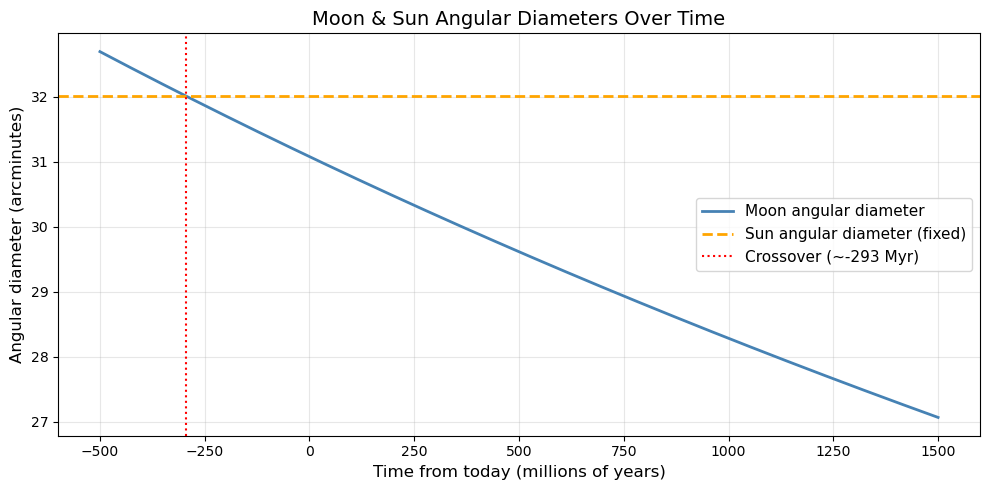

In [22]:
# Convert radians to arcminutes for a more intuitive unit
# 1 radian = (180/pi)*60 arcminutes
RAD_TO_ARCMIN = (180 / np.pi) * 60

theta_moon_arcmin = theta_moon_arr * RAD_TO_ARCMIN
theta_sun_arcmin  = angular_size(D_sun, d_sun) * RAD_TO_ARCMIN

# x-axis: years from now (in millions of years)
x_Myr = years / 1e6

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_Myr, theta_moon_arcmin, color="steelblue", lw=2, label="Moon angular diameter")
ax.axhline(theta_sun_arcmin, color="orange", lw=2, linestyle="--", label="Sun angular diameter (fixed)")
ax.axvline(t_crossover / 1e6, color="red", lw=1.5, linestyle=":", label=f"Crossover (~{t_crossover/1e6:.0f} Myr)")

ax.set_xlabel("Time from today (millions of years)", fontsize=12)
ax.set_ylabel("Angular diameter (arcminutes)", fontsize=12)
ax.set_title("Moon & Sun Angular Diameters Over Time", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot1_angular_diameter.png", dpi=150)
plt.show()

---
## 5. Plot 2: Moon/Sun Angular Size Ratio $R(t)$

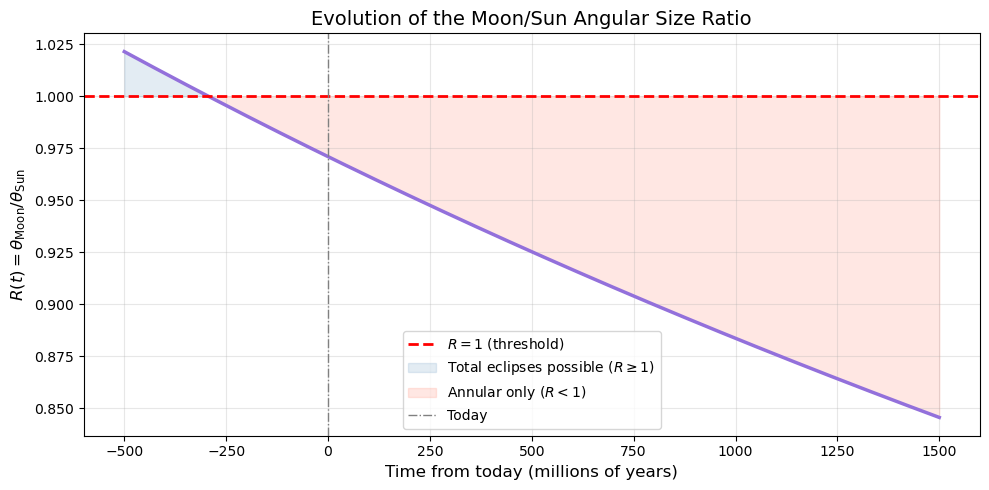

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_Myr, R_arr, color="mediumpurple", lw=2.5)

# Critical threshold
ax.axhline(1.0, color="red", lw=2, linestyle="--", label="$R = 1$ (threshold)")

# Shade regions
ax.fill_between(x_Myr, R_arr, 1.0,
                where=(R_arr >= 1.0),
                alpha=0.15, color="steelblue",
                label="Total eclipses possible ($R \\geq 1$)")
ax.fill_between(x_Myr, R_arr, 1.0,
                where=(R_arr < 1.0),
                alpha=0.15, color="tomato",
                label="Annular only ($R < 1$)")

# Mark today
ax.axvline(0, color="gray", lw=1, linestyle="-.", label="Today")

# Mark NASA catalog eclipse magnitudes as scatter (optional — add after catalog is loaded)
# TODO: overlay NASA magnitude data here once catalog is clean
# df_total = df[df["Type_Simple"] == "T"]
# ax.scatter((df_total["Year"] - YEAR_0)/1e6, df_total["Ecl_Mag"],
#            s=1, color="steelblue", alpha=0.3, label="NASA total eclipses")

ax.set_xlabel("Time from today (millions of years)", fontsize=12)
ax.set_ylabel(r"$R(t) = \theta_\mathrm{Moon} / \theta_\mathrm{Sun}$", fontsize=12)
ax.set_title("Evolution of the Moon/Sun Angular Size Ratio", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot2_ratio.png", dpi=150)
plt.show()

---
## 6. Plot 3: Superimposed Sun & Moon Disk Comparison

This draws the Moon and Sun as circles at their correct *relative* angular sizes for a given year.

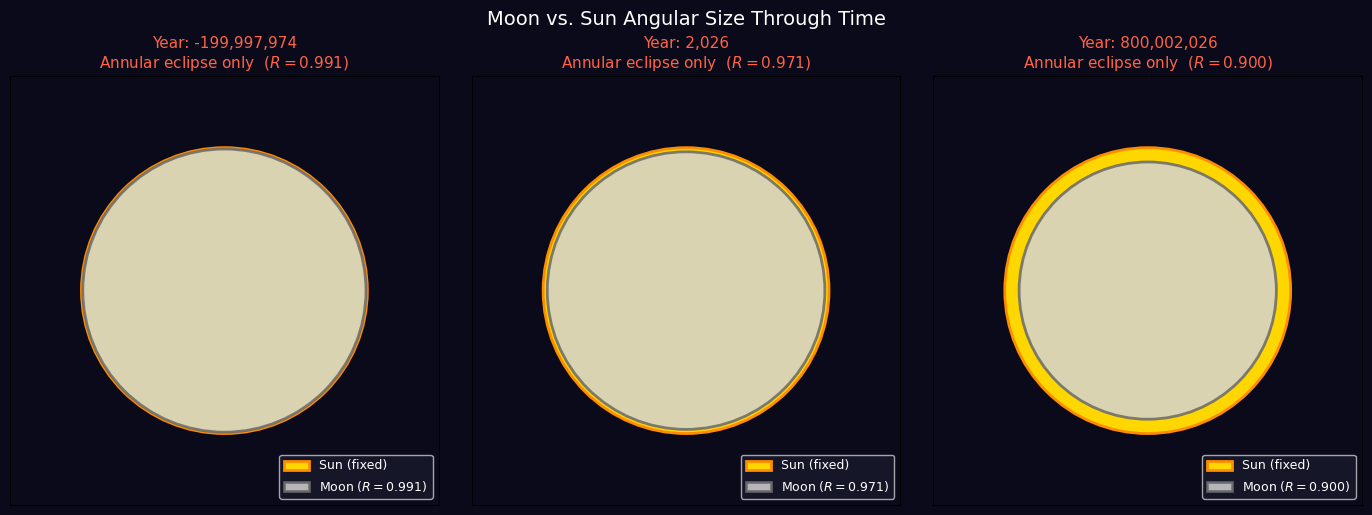

In [24]:
def draw_eclipse_disks(year, ax=None, title=None):
    """
    Draw superimposed Sun (orange) and Moon (gray) disks
    at their relative angular sizes for the given year.
    
    The Sun is fixed at radius=1.0; the Moon is scaled to R(t).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    t_offset = year - YEAR_0
    R = ratio_R(t_offset)

    # Sun disk (fixed reference radius = 1.0)
    sun = patches.Circle((0, 0), radius=1.0,
                          color="gold", ec="darkorange", lw=2,
                          label=f"Sun (fixed)")
    # Moon disk (radius scaled by R)
    moon = patches.Circle((0, 0), radius=R,
                           color="lightgray", ec="dimgray", lw=2, alpha=0.85,
                           label=f"Moon ($R={R:.3f}$)")

    ax.add_patch(sun)
    ax.add_patch(moon)

    # Formatting
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.set_facecolor("#0a0a1a")  # dark sky
    ax.set_xticks([])
    ax.set_yticks([])

    eclipse_label = "Total eclipse possible" if R >= 1.0 else "Annular eclipse only"
    color_label   = "limegreen" if R >= 1.0 else "tomato"
    ax.set_title(title or f"Year: {year:,.0f}\n{eclipse_label}  ($R = {R:.3f}$)",
                 fontsize=11, color=color_label)
    ax.legend(loc="lower right", fontsize=9,
              facecolor="#1a1a2e", labelcolor="white")

    return R


# Show three snapshots: past, present, future
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#0a0a1a")

example_years = [
    YEAR_0 - 200_000_000,   # 200 million years ago
    YEAR_0,                  # today
    YEAR_0 + 800_000_000,   # 800 million years in future
]

for ax, yr in zip(axes, example_years):
    draw_eclipse_disks(yr, ax=ax)

plt.suptitle("Moon vs. Sun Angular Size Through Time",
             fontsize=14, color="white", y=1.02)
plt.tight_layout()
plt.savefig("plot3_disks.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

---
## 7. Interactive Widget: Eclipse Type by Year

Drag the slider to any year and see whether a total eclipse would be possible.

In [25]:
from ipywidgets import interact, IntSlider

def interactive_disks(years_from_now=0):
    year = YEAR_0 + years_from_now * 1_000_000  # slider in millions of years
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor("#0a0a1a")
    draw_eclipse_disks(year, ax=ax)
    plt.tight_layout()
    plt.show()

slider = IntSlider(
    value=0,
    min=-500,
    max=1500,
    step=10,
    description="Myr from now:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="600px")
)

interact(interactive_disks, years_from_now=slider)

interactive(children=(IntSlider(value=0, description='Myr from now:', layout=Layout(width='600px'), max=1500, …

<function __main__.interactive_disks(years_from_now=0)>

---
## Next Steps

- [ ] Download `5MKSEcatalog.txt` locally and confirm catalog parsing
- [ ] Overlay NASA eclipse magnitude data on Plot 2 (the commented-out scatter in §5)
- [ ] Refine plot styling and add figure captions for your report
- [ ] Write up results: what year does the crossover occur? How does it compare to published estimates?
- [ ] Consider whether to account for Earth's orbital eccentricity (Moon distance varies ±6% each month)